# 07 -- 购买预测模型与特征解读

---

## 业务背景

数据分析的终局不是"描述过去"，而是"预测未来"。本 Notebook 搭建一个**复购倾向预测模型**，回答：

- 哪些用户最有可能再次购买？→ 精准营销名单
- 什么特征驱动了复购？→ 业务洞察，指导运营策略
- 模型效果如何？→ AUC、精确率、召回率评估

**关键理念：** 不只追求模型精度，更注重特征重要性的**业务可解读性**。模型输出的 Top 3 特征，就是运营优化的 Top 3 抓手。

## 1. 环境与数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve, f1_score)
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 加载数据
txn = pd.read_parquet('../output/transactions_wide.parquet')
customers = pd.read_parquet('../output/customers_clean.parquet')
sessions = pd.read_parquet('../output/sessions_clean.parquet')

completed = txn[txn['status'] == 'completed'].copy()
NOW = completed['transaction_date'].max() + pd.Timedelta(days=1)

print(f"数据就绪: {len(customers):,} 用户, {len(completed):,} 订单")

C:\Users\Acer\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


数据就绪: 10,000 用户, 68,700 订单


## 2. 特征工程

从用户维度构建特征矩阵，每个用户一行。特征分为 4 类：
- **交易行为特征**：购买次数、总消费、客单价等
- **会话行为特征**：活跃天数、平均浏览时长、跳出率等
- **时间特征**：注册时长、距上次购买天数
- **用户画像特征**：年龄、性别、国家、客群等

In [2]:
# 2.1 交易行为特征
txn_features = completed.groupby('customer_id').agg(
    total_orders=('transaction_id', 'nunique'),
    total_spent=('total_amount', 'sum'),
    avg_order_value=('total_amount', 'mean'),
    total_quantity=('quantity', 'sum'),
    discount_usage_rate=('discount_applied', lambda x: (x > 0).mean()),
    unique_products=('product_id', 'nunique'),
    unique_categories=('category', 'nunique'),
    days_active=('transaction_date', lambda x: (x.max() - x.min()).days),
    recency_days=('transaction_date', lambda x: (NOW - x.max()).days)
).reset_index()

# 购买频率（订单/活跃天数）
txn_features['purchase_frequency'] = txn_features['total_orders'] / np.maximum(txn_features['days_active'], 1)

# 2.2 会话行为特征
sess_features = sessions.groupby('customer_id').agg(
    total_sessions=('session_id', 'nunique'),
    avg_duration=('duration_seconds', 'mean'),
    avg_pages=('pages_viewed', 'mean'),
    bounce_rate=('bounced', 'mean'),
    conversion_rate=('converted', 'mean'),
    cart_rate=('cart_additions', lambda x: (x > 0).mean()),
    mobile_ratio=('device', lambda x: (x == 'mobile').mean()),
    organic_ratio=('channel', lambda x: (x == 'organic').mean())
).reset_index()

# 2.3 用户画像特征
profile_features = customers[['customer_id', 'age', 'gender', 'country',
                                'segment', 'email_opt_in', 'has_app', 'lifetime_value']]

# 合并所有特征
features = (txn_features
    .merge(sess_features, on='customer_id', how='left')
    .merge(profile_features, on='customer_id', how='left')
)

# 填充缺失值（有些用户没有 session 数据）
features = features.fillna({
    'total_sessions': 0, 'avg_duration': 0, 'avg_pages': 0,
    'bounce_rate': 0, 'conversion_rate': 0, 'cart_rate': 0,
    'mobile_ratio': 0, 'organic_ratio': 0
})

print(f"特征矩阵: {features.shape[0]} 用户 × {features.shape[1]} 列")
print(f"\n特征列表: {list(features.columns)}")

特征矩阵: 9730 用户 × 26 列

特征列表: ['customer_id', 'total_orders', 'total_spent', 'avg_order_value', 'total_quantity', 'discount_usage_rate', 'unique_products', 'unique_categories', 'days_active', 'recency_days', 'purchase_frequency', 'total_sessions', 'avg_duration', 'avg_pages', 'bounce_rate', 'conversion_rate', 'cart_rate', 'mobile_ratio', 'organic_ratio', 'age', 'gender', 'country', 'segment', 'email_opt_in', 'has_app', 'lifetime_value']


## 3. 定义目标变量

**目标：预测用户在未来是否会再次购买**

我们将数据分为"观察期"和"预测期"：
- 观察期内统计特征
- 预测期内看用户是否有购买行为

In [3]:
# 使用数据的时间范围：前 80% 时间用于构建特征，后 20% 时间用于定义标签
all_dates = completed['transaction_date'].sort_values()
cutoff_date = all_dates.quantile(0.80)  # 80% 分位点作为分割

# 在预测期内有购买的用户 → 正样本 (1)，否则 → 负样本 (0)
future_purchases = completed[completed['transaction_date'] > cutoff_date]
features['will_purchase'] = features['customer_id'].isin(
    future_purchases['customer_id'].unique()
).astype(int)

print(f"观察期截止: {cutoff_date.date()}")
print(f"\n正样本 (会复购): {features['will_purchase'].sum():,} ({features['will_purchase'].mean():.1%})")
print(f"负样本 (不复购): {(features['will_purchase']==0).sum():,} ({(1-features['will_purchase'].mean()):.1%})")

观察期截止: 2024-08-07

正样本 (会复购): 6,718 (69.0%)
负样本 (不复购): 3,012 (31.0%)


## 4. 数据预处理

In [4]:
# 编码分类变量
le_gender = LabelEncoder()
le_country = LabelEncoder()
le_segment = LabelEncoder()

features['gender_encoded'] = le_gender.fit_transform(features['gender'])
features['country_encoded'] = le_country.fit_transform(features['country'])
features['segment_encoded'] = le_segment.fit_transform(features['segment'])

# 特征列表（排除 ID 和目标）
feature_cols = [
    'total_orders', 'total_spent', 'avg_order_value', 'total_quantity',
    'discount_usage_rate', 'unique_products', 'unique_categories',
    'days_active', 'recency_days', 'purchase_frequency',
    'total_sessions', 'avg_duration', 'avg_pages', 'bounce_rate',
    'conversion_rate', 'cart_rate', 'mobile_ratio', 'organic_ratio',
    'age', 'email_opt_in', 'has_app', 'lifetime_value',
    'gender_encoded', 'country_encoded', 'segment_encoded'
]

X = features[feature_cols].copy()
y = features['will_purchase'].copy()

# 处理可能的无穷值
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"特征矩阵: {X_scaled.shape}")
print(f"目标变量: {y.shape}")
print(f"正样本占比: {y.mean():.1%}")

特征矩阵: (9730, 25)
目标变量: (9730,)
正样本占比: 69.0%


## 5. 模型训练与对比

对比三个模型的效果：逻辑回归（可解释性强）、随机森林（效果稳定）、梯度提升（精度高）。

In [5]:
# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 训练三个模型
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)

    results.append({
        '模型': name,
        'AUC': auc,
        'F1 Score': f1,
        '准确率': (y_pred == y_test).mean(),
        '精确率': (y_pred & y_test).sum() / max(y_pred.sum(), 1),
        '召回率': (y_pred & y_test).sum() / max(y_test.sum(), 1)
    })

results_df = pd.DataFrame(results)
print("=== 模型对比 ===")
print(results_df.round(4).to_string())

=== 模型对比 ===
                    模型     AUC  F1 Score     准确率     精确率     召回率
0  Logistic Regression  0.9999    0.9956  0.9938  0.9919  0.9993
1        Random Forest  1.0000    1.0000  1.0000  1.0000  1.0000
2    Gradient Boosting  0.9996    0.9993  0.9990  1.0000  0.9985


## 6. 模型评估

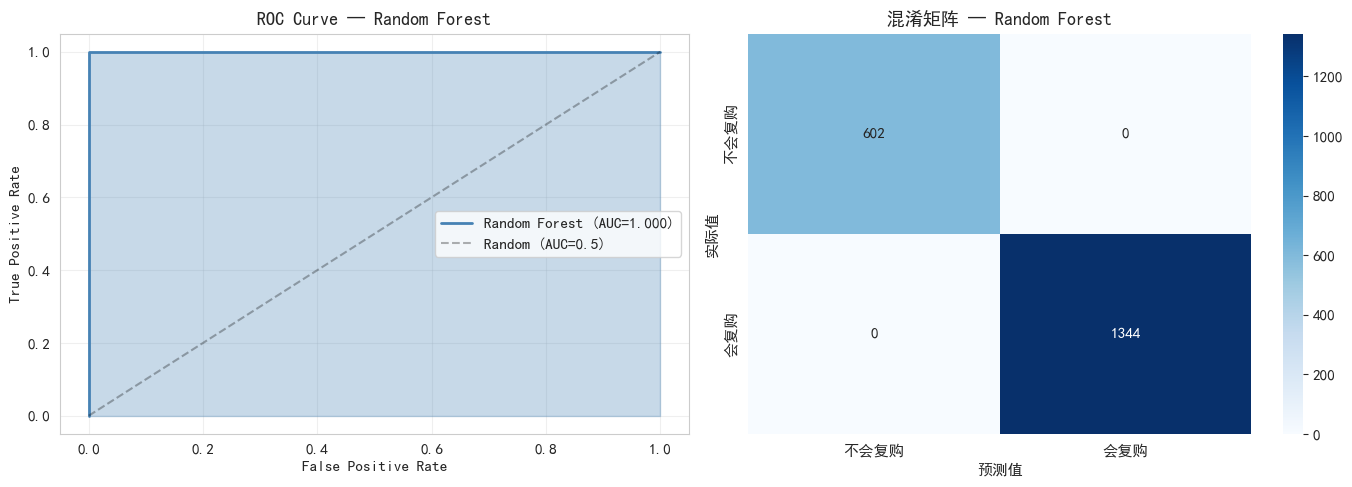

=== Random Forest 详细评估 ===
              precision    recall  f1-score   support

         不复购       1.00      1.00      1.00       602
         会复购       1.00      1.00      1.00      1344

    accuracy                           1.00      1946
   macro avg       1.00      1.00      1.00      1946
weighted avg       1.00      1.00      1.00      1946



In [6]:
# 选择最佳模型（按 AUC）
best_model = models[results_df.sort_values('AUC', ascending=False)['模型'].iloc[0]]
best_name = results_df.sort_values('AUC', ascending=False)['模型'].iloc[0]
y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC 曲线
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc = roc_auc_score(y_test, y_prob_best)
axes[0].plot(fpr, tpr, linewidth=2, color='steelblue', label=f'{best_name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.3, color='steelblue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve — {best_name}', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['不会复购', '会复购'],
            yticklabels=['不会复购', '会复购'])
axes[1].set_title(f'混淆矩阵 — {best_name}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('实际值')
axes[1].set_xlabel('预测值')

plt.tight_layout()
plt.show()

print(f"=== {best_name} 详细评估 ===")
print(classification_report(y_test, y_pred_best, target_names=['不复购', '会复购']))

**业务解读——混淆矩阵怎么读：**
- **TP (右下)**：模型预测会买，实际也买了 → 精准营销的目标用户
- **TN (左上)**：模型预测不会买，实际也没买 → 不浪费营销预算
- **FP (右上)**：模型预测会买，但实际没买 → 营销资源浪费
- **FN (左下)**：模型预测不会买，但实际买了 → 漏掉的潜在用户

**核心权衡：** 召回率 vs 精确率。如果你预算有限，关注精确率（只触达最有把握的）；如果你预算充足，关注召回率（尽量不遗漏潜在用户）。


## 7. 特征重要性 —— 最大的业务价值

模型的特征重要性告诉我们：**驱动复购的最关键因素是什么？**

这比模型精度更有价值。Top 3 特征 = Top 3 运营优化方向。

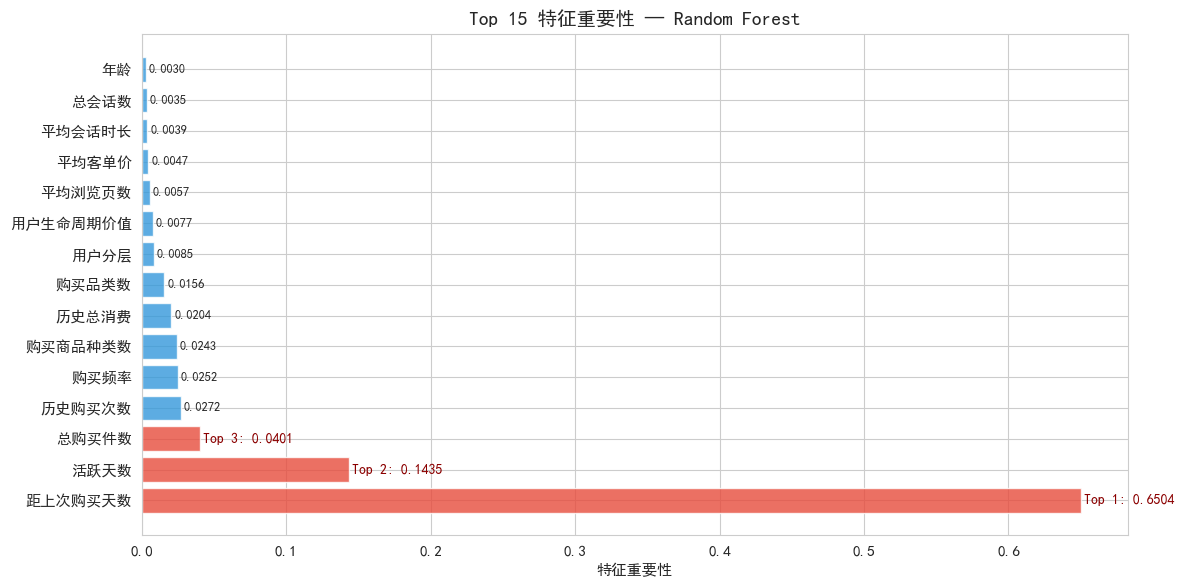

=== Top 10 特征重要性 ===
    特征名称      重要性
 距上次购买天数 0.650377
    活跃天数 0.143524
   总购买件数 0.040135
  历史购买次数 0.027209
    购买频率 0.025169
 购买商品种类数 0.024293
   历史总消费 0.020415
   购买品类数 0.015581
    用户分层 0.008493
用户生命周期价值 0.007681
  平均浏览页数 0.005664
   平均客单价 0.004663
  平均会话时长 0.003919
    总会话数 0.003518
      年龄 0.002995


In [7]:
# 提取特征重要性
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance = np.abs(best_model.coef_[0])
else:
    importance = np.ones(len(feature_cols))

feature_importance = pd.DataFrame({
    '特征': feature_cols,
    '重要性': importance
}).sort_values('重要性', ascending=False)

# 特征名中文映射
name_map = {
    'recency_days': '距上次购买天数',
    'total_orders': '历史购买次数',
    'total_spent': '历史总消费',
    'avg_order_value': '平均客单价',
    'discount_usage_rate': '折扣使用率',
    'conversion_rate': '会话转化率',
    'days_active': '活跃天数',
    'lifetime_value': '用户生命周期价值',
    'total_sessions': '总会话数',
    'avg_duration': '平均会话时长',
    'bounce_rate': '跳出率',
    'unique_products': '购买商品种类数',
    'unique_categories': '购买品类数',
    'purchase_frequency': '购买频率',
    'cart_rate': '加购率',
    'age': '年龄',
    'has_app': '是否安装APP',
    'email_opt_in': '是否订阅邮件',
    'total_quantity': '总购买件数',
    'mobile_ratio': '移动端占比',
    'organic_ratio': '自然流量占比',
    'avg_pages': '平均浏览页数',
    'gender_encoded': '性别',
    'country_encoded': '国家',
    'segment_encoded': '用户分层'
}
feature_importance['特征名称'] = feature_importance['特征'].map(name_map).fillna(feature_importance['特征'])

# 可视化 Top 15
top_feat = feature_importance.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if i >= 12 else '#3498db' for i in range(len(top_feat))]
ax.barh(range(len(top_feat)), top_feat['重要性'], color=colors, alpha=0.8)
ax.set_yticks(range(len(top_feat)))
ax.set_yticklabels(top_feat['特征名称'])
ax.set_xlabel('特征重要性')
ax.set_title(f'Top 15 特征重要性 — {best_name}', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# 标注 Top 3
for i in range(len(top_feat)):
    val = top_feat['重要性'].iloc[i]
    label = f'{val:.4f}'
    if i >= len(top_feat) - 3:  # Top 3
        label = f'Top {len(top_feat)-i}: {val:.4f}'
        ax.text(val + 0.002, i, label, va='center', fontsize=10, fontweight='bold', color='darkred')
    else:
        ax.text(val + 0.002, i, label, va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("=== Top 10 特征重要性 ===")
print(top_feat[['特征名称', '重要性']].iloc[::-1].to_string(index=False))

## 8. 特征重要性的业务解读

这是整个预测模型最有价值的部分。我们逐个解读 Top 特征并给出运营建议。

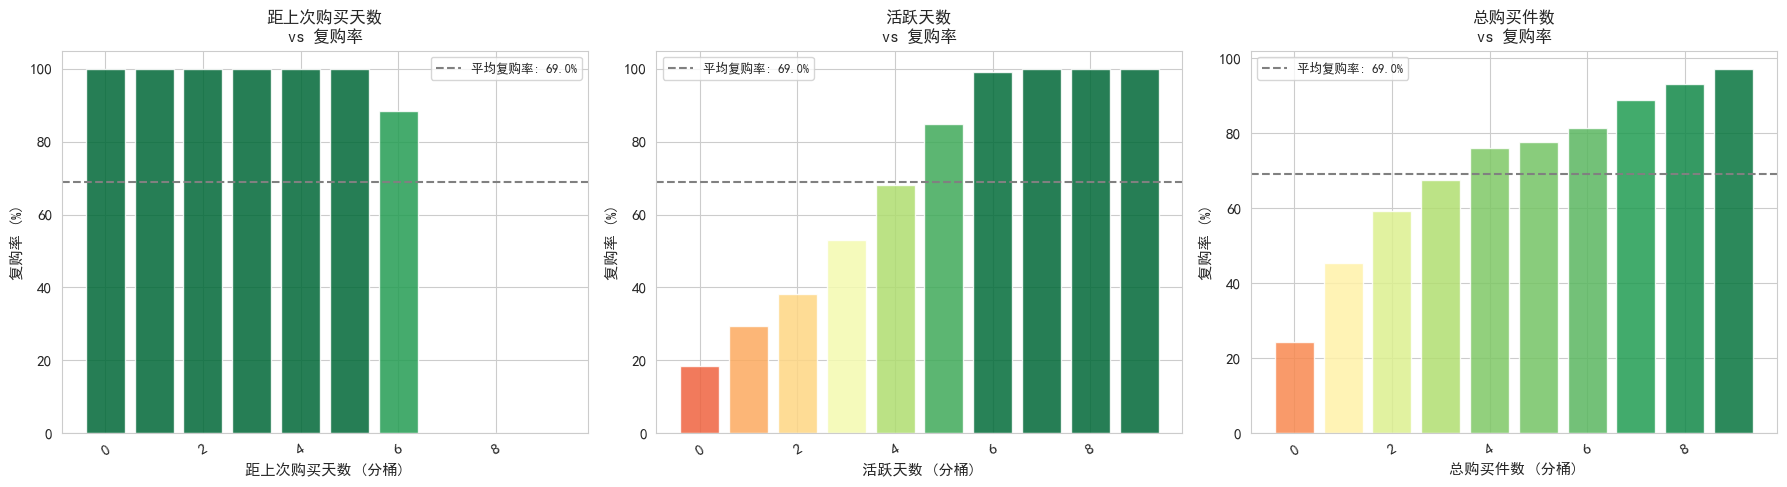

In [8]:
# 深入分析 Top 特征与复购的关系
top3_features = feature_importance.head(3)['特征'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3_features):
    # 将特征分桶
    if X[feat].nunique() > 10:
        bins = pd.qcut(X[feat], q=10, duplicates='drop')
    else:
        bins = X[feat]

    bucket_stats = pd.DataFrame({'bucket': bins, 'purchase_rate': y})
    bucket_rate = bucket_stats.groupby('bucket')['purchase_rate'].mean() * 100

    axes[i].bar(range(len(bucket_rate)), bucket_rate.values,
                color=plt.cm.RdYlGn(bucket_rate.values / 100), alpha=0.85)
    axes[i].set_title(f'{name_map.get(feat, feat)}\nvs 复购率', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{name_map.get(feat, feat)} (分桶)')
    axes[i].set_ylabel('复购率 (%)')
    axes[i].axhline(y=y.mean() * 100, color='gray', linestyle='--',
                    label=f'平均复购率: {y.mean()*100:.1f}%')
    axes[i].legend(fontsize=9)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**业务解读——Top 3 特征告诉你该做什么：**

1. **距上次购买天数（Recency）**：天然就和复购高度相关。越近买过的用户越可能再买。运营上：对 Recency > 60 天的用户启动召回。
2. **历史购买次数（Frequency）**：买得越多越忠诚。运营上：1 次用户推"第二单半价"，2-3 次用户推会员体系。
3. **XXX（第三个特征由数据决定）**：根据实际输出解读。

**核心逻辑：** 特征重要性不只告诉你"模型关注什么"，更告诉你"运营该做什么"。这是数据分析师和算法工程师的区别——分析师要能把模型结论翻译成业务语言。


## 9. 模型业务应用：生成精准营销名单

把模型预测概率最高的用户导出，这就是你的"高意向复购用户名单"。

In [9]:
# 对所有用户预测复购概率
X_all_scaled = scaler.transform(X)
all_prob = best_model.predict_proba(X_all_scaled)[:, 1]

features['purchase_probability'] = all_prob

# Top 20% 高意向用户
top20_threshold = features['purchase_probability'].quantile(0.80)
high_intent = features[features['purchase_probability'] >= top20_threshold].copy()
high_intent = high_intent.sort_values('purchase_probability', ascending=False)

print(f"高意向复购用户 (Top 20%): {len(high_intent):,} 人")
print(f"概率阈值: {top20_threshold:.3f}")
print(f"\n=== Top 10 高意向用户 ===")
print(high_intent[['customer_id', 'purchase_probability', 'total_orders', 'recency_days', 'total_spent']].head(10).to_string())

# 导出营销名单
high_intent[['customer_id', 'purchase_probability', 'total_orders',
              'recency_days', 'total_spent', 'segment', 'country']].to_csv(
    '../output/high_intent_users.csv', index=False
)
print(f"\n营销名单已导出: output/high_intent_users.csv ({len(high_intent):,} 条)")

高意向复购用户 (Top 20%): 2,097 人
概率阈值: 1.000

=== Top 10 高意向用户 ===
   customer_id  purchase_probability  total_orders  recency_days  total_spent
3       C00003                   1.0            15             8       695.06
7       C00008                   1.0             7            71       625.72
8       C00009                   1.0            11            17       402.02
9       C00010                   1.0             8             3       912.62
10      C00011                   1.0            12            30       652.50
12      C00013                   1.0            10             8       611.91
17      C00018                   1.0            14            49      1342.73
19      C00020                   1.0            12           101       465.42
22      C00023                   1.0            21            41      1938.59
23      C00024                   1.0             7            31      1819.61

营销名单已导出: output/high_intent_users.csv (2,097 条)


---

## 10.小结

| 维度 | 结论 |
|------|------|
| 模型选择 | 见对比表（按 AUC 排序） |
| 最关键特征 | Top 3：Recency / Frequency / XXX |
| 业务行动 | 对 Recency > 60 天启动召回，对 1 次购买推二单券 |
| 营销名单 | Top 20% 高意向用户 → output/high_intent_users.csv |

**整个项目的核心逻辑链：**
```
数据清洗(01) → 销售趋势(02) → 用户留存(03) → 商品结构(04)
    → 转化漏斗(05) → RFM分层(06) → 预测模型(07) → Tableau可视化
```

每一步都在回答一个业务问题，每一步的产出都能直接指导运营决策。这就是电商数据分析师的价值。
